# Calibration of Probabilities for Diabetes Dataset

This notebook studies the calibration of probabilistic classifiers using the Diabetes dataset from OpenML.


## 1. Import Libraries

In [1]:
"""Calibration analysis for the Diabetes dataset."""

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import fetch_openml
from sklearn.experimental import enable_iterative_imputer # pylint: disable=unused-import
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss


project_root = Path.cwd().parent
sys.path.append(str(project_root))

from scripts.calibration import PlattScaling, IsotonicRegression
from scripts.visualization import (
    plot_reliability_diagram,
    compare_reliability_diagrams,
    compare_all_calibrations
)

## 2. Load the Dataset

In [2]:
diabetes = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True
)

In [3]:
print("Dataset shape:", diabetes["data"].shape)
print("Target name:", diabetes["target"].name)
print("Target classes:", diabetes["target"].unique())

Dataset shape: (768, 8)
Target name: class
Target classes: ['tested_positive', 'tested_negative']
Categories (2, str): ['tested_negative', 'tested_positive']


In [4]:
X = diabetes["data"].copy()

y = diabetes["target"].map({
    "tested_negative": 0,
    "tested_positive": 1
}).astype(int)

0 = tested_negative

1 = tested_positive

In [5]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target values:", y.unique())

Features shape: (768, 8)
Target shape: (768,)
Target values: [1 0]


In [6]:
y = y.rename("target")

df = pd.concat(
    [X, y],
    axis=1
)

## 3. Exploratory Data Analysis (EDA)

### General describe

In [7]:
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

Number of observations: 768
Number of variables: 9


In [8]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   target  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


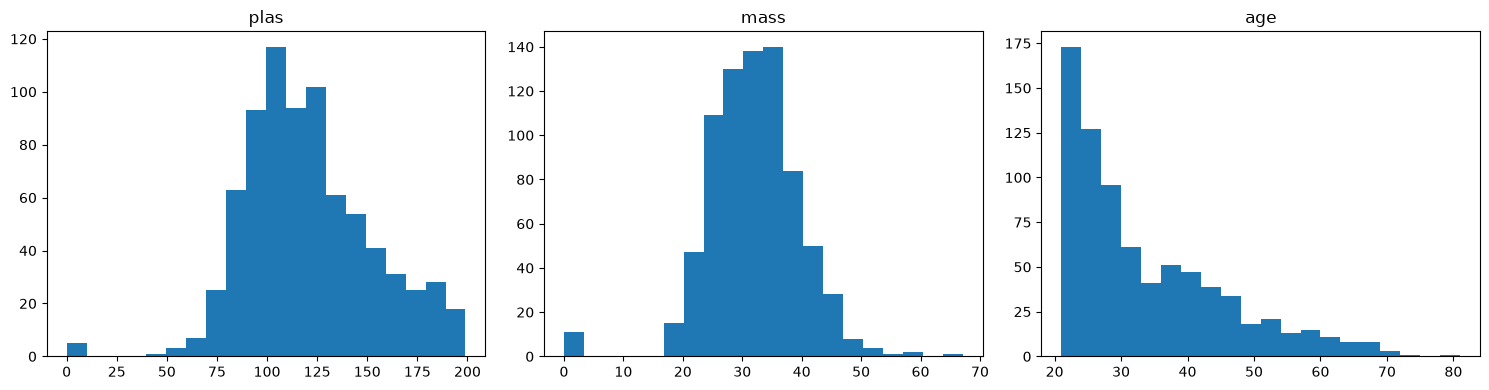

In [11]:
features = [
    "plas",
    "mass",
    "age"
]

plt.figure(figsize=(15, 4))

for i, feature in enumerate(features):

    plt.subplot(1, 3, i + 1)

    plt.hist(df[feature], bins=20)

    plt.title(feature)

plt.tight_layout()
plt.show()

### Target distribution

In [12]:
target_summary = pd.DataFrame({
    "Count": df["target"].value_counts().sort_index(),
    "Percentage": (
        df["target"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "Tested Negative",
    "Tested Positive"
]

display(target_summary)

,Count,Percentage
Tested Negative,500,65.1
Tested Positive,268,34.9


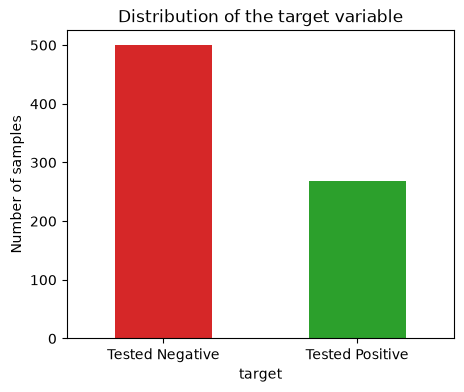

In [13]:
plt.figure(figsize=(5, 4))

df["target"].value_counts().sort_index().plot(
    kind="bar",
    color=["#d62728", "#2ca02c"]
)

plt.xticks(
    [0, 1],
    ["Tested Negative", "Tested Positive"],
    rotation=0
)

plt.ylabel("Number of samples")
plt.title("Distribution of the target variable")

plt.show()

### Missing values

In [14]:
df.isnull().sum()

preg      0
plas      0
pres      0
skin      0
insu      0
mass      0
pedi      0
age       0
target    0
dtype: int64

In [15]:
(df == 0).sum()

preg      111
plas        5
pres       35
skin      227
insu      374
mass       11
pedi        0
age         0
target    500
dtype: int64

Although the dataset contains no explicit missing values, some features contain zero values that are not physiologically plausible, such as glucose concentration, blood pressure, skin thickness, insulin, and BMI. These zeros are therefore treated as missing values and imputed before model training.

I will analise them in data preprocessing.

### Correlation matrix

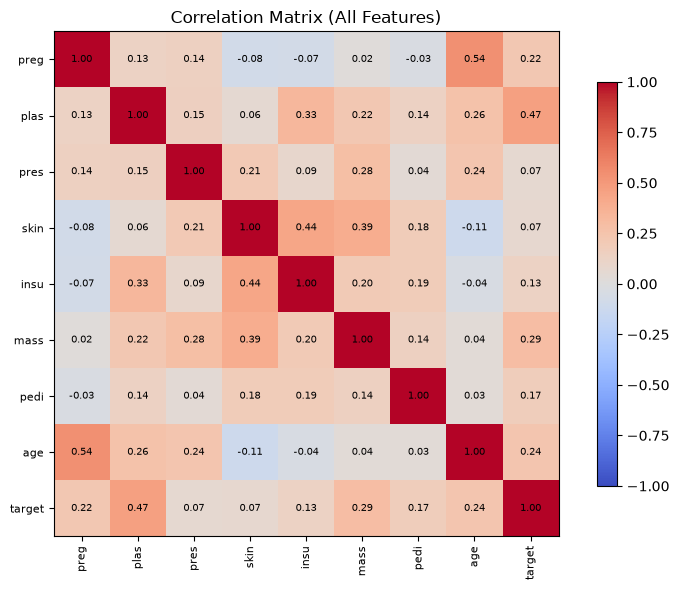

In [16]:
corr = df.corr()

plt.figure(figsize=(8, 6))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="nearest"
)

plt.colorbar(shrink=0.8)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=8
)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Matrix (All Features)", fontsize=12)

plt.tight_layout()
plt.show()

The target variable shows a moderate class imbalance, with approximately 65% negative and 35% positive cases. The correlation matrix indicates that plasma glucose concentration (plas) has the strongest correlation with the target (0.49), followed by body mass index (mass) and insulin (insu). Some features also show moderate correlations with each other. At this stage, the EDA is based on the original data: implausible zero values in some clinical variables have not yet been treated and will be handled during the preprocessing step using imputation.

## 4. Data Preprocessing

### Missing values, target and split

In [17]:
columns_with_missing_zeros = [
    "plas",
    "pres",
    "skin",
    "insu",
    "mass"
]

df[columns_with_missing_zeros] = (
    df[columns_with_missing_zeros].replace(0, np.nan)
)

In [18]:
df.isnull().sum()

preg        0
plas        5
pres       35
skin      227
insu      374
mass       11
pedi        0
age         0
target      0
dtype: int64

In [19]:
x = df.drop(columns="target")
y = df["target"]

In [20]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

x_cal, x_test, y_cal, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.40,
    random_state=42,
    stratify=y_temp
)

In [21]:
print("Training set:", x_train.shape)
print("Calibration set:", x_cal.shape)
print("Test set:", x_test.shape)

Training set: (384, 8)
Calibration set: (230, 8)
Test set: (154, 8)


In [22]:
mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

x_train_imputed = mice_imputer.fit_transform(x_train)

x_cal_imputed = mice_imputer.transform(x_cal)

x_test_imputed = mice_imputer.transform(x_test)

The implausible zero values were first converted to missing values. 

MICE-style iterative imputation is used to estimate the missing values based on the relationships among the remaining features.

To avoid data leakage, the imputer is fitted only on the training data and subsequently applied to the calibration and test sets.

In [23]:
x_train = pd.DataFrame(
    x_train_imputed,
    columns=x.columns,
    index=x_train.index
)

x_cal = pd.DataFrame(
    x_cal_imputed,
    columns=x.columns,
    index=x_cal.index
)

x_test = pd.DataFrame(
    x_test_imputed,
    columns=x.columns,
    index=x_test.index
)

#### Class Distribution after the Split

In [24]:
print("Training")
print(y_train.value_counts(normalize=True))

print("\nCalibration")
print(y_cal.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Training
target
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Calibration
target
0    0.652174
1    0.347826
Name: proportion, dtype: float64

Test
target
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## 5. Logistic regression

#### Standardization

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_cal_scaled = scaler.transform(x_cal)
X_test_scaled = scaler.transform(x_test)

### 5.1 Train Logistic Regression

In [26]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

#### Predicted Probabilities

In [27]:
y_prob_test_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

#### Predicted Classes

In [28]:
y_pred_test_lr = log_reg.predict(X_test_scaled)

### 5.2 Evaluation before Calibration

In [29]:
accuracy_lr = accuracy_score(y_test, y_pred_test_lr)
logloss_lr = log_loss(y_test, y_prob_test_lr)
brier_lr = brier_score_loss(y_test, y_prob_test_lr)

print(f"Accuracy:    {accuracy_lr:.4f}")
print(f"Log-loss:    {logloss_lr:.4f}")
print(f"Brier score: {brier_lr:.4f}")

Accuracy:    0.7468
Log-loss:    0.5100
Brier score: 0.1687


Accuracy: higher values indicate better classification performance.

Log-loss: lower values indicate better probabilistic predictions.

Brier score: lower values indicate better calibrated probability estimates.

#### Reliability diagram before calibration

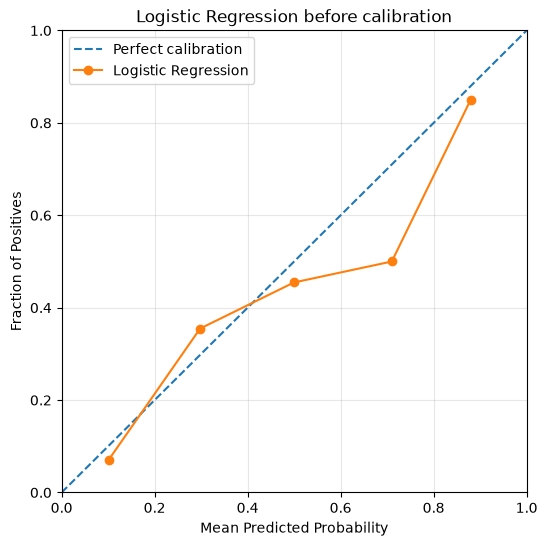

In [30]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr,
    model_label="Logistic Regression",
    title="Logistic Regression before calibration",
    n_bins=5
)

The Logistic Regression achieves an accuracy of approximately 0.75. The reliability diagram shows some deviations from perfect calibration, particularly for intermediate-to-high predicted probabilities, where the model tends to overestimate the probability of the positive class. Therefore, probability calibration may improve the reliability of its predictions.

### 5.3 Calibration with Platt Scaling

Platt Scaling is used to correct the probabilities produced by a model without retraining the model itself. Platt uses a separate set of data (the calibration set) to understand what actually happens in practice.

Transform the score into a probability using a sigmoid: 
sigmoid(A * score + B) = 1 / (1 + exp(-(A * score + B)))

Platt Scaling does not aim to make the model better at classification; instead, it aims to make the model's confidence in its predictions more reliable.

Platt Scaling is applied using the independent calibration set.  
The method learns a sigmoid transformation from the model scores to calibrated probabilities, without retraining the original classifier.

In [31]:
scores_cal_lr = log_reg.decision_function(X_cal_scaled)
scores_test_lr = log_reg.decision_function(X_test_scaled)

In [32]:
platt_lr = PlattScaling(
    learning_rate=0.01,
    max_iter=10000,
    tolerance=1e-7
)

In [33]:
platt_lr.fit(scores_cal_lr, y_cal)

#### Predicted Probabilities

In [34]:
y_prob_test_lr_platt = platt_lr.predict_proba(scores_test_lr)

#### Predicted Classes

In [35]:
y_pred_test_lr_platt = (y_prob_test_lr_platt >= 0.5).astype(int)

### 5.4 Evaluation after Platt Scaling

In [36]:
accuracy_lr_platt = accuracy_score(y_test, y_pred_test_lr_platt)
logloss_lr_platt = log_loss(y_test, y_prob_test_lr_platt)
brier_lr_platt = brier_score_loss(y_test, y_prob_test_lr_platt)

print(f"Accuracy:    {accuracy_lr_platt:.4f}")
print(f"Log-loss:    {logloss_lr_platt:.4f}")
print(f"Brier score: {brier_lr_platt:.4f}")

Accuracy:    0.7403
Log-loss:    0.5032
Brier score: 0.1664


#### Reliability diagram after calibration

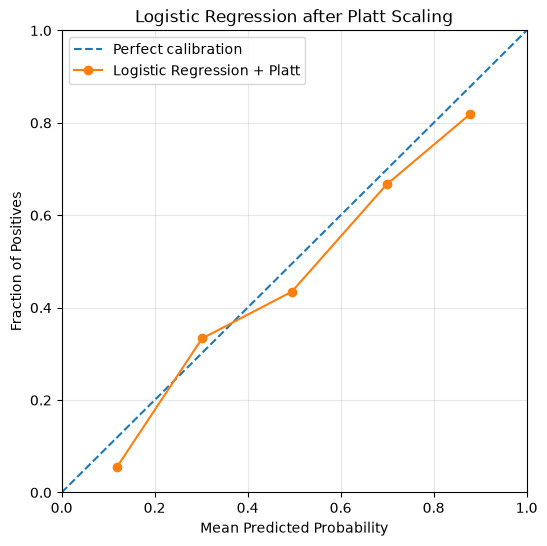

In [37]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr_platt,
    model_label="Logistic Regression + Platt",
    title="Logistic Regression after Platt Scaling",
    n_bins=5
)

### 5.5 Evaluation before and after Platt Scaling

In [38]:
comparison_platt_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],
    "After Platt": [
        accuracy_lr_platt,
        logloss_lr_platt,
        brier_lr_platt
    ]
})

display(comparison_platt_lr)

,Metric,Before calibration,After Platt
0,Accuracy,0.746753,0.740260
1,Log-loss,0.510001,0.503197
2,Brier score,0.168656,0.166436


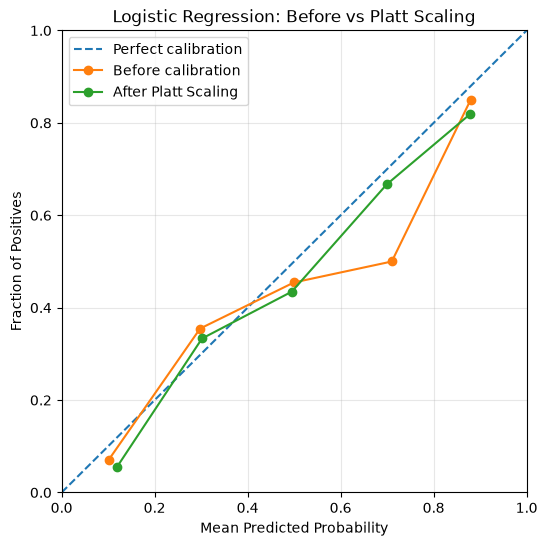

In [39]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_after=y_prob_test_lr_platt,
    label_before="Before calibration",
    label_after="After Platt Scaling",
    title="Logistic Regression: Before vs Platt Scaling",
    n_bins=5
)

Platt Scaling slightly improves the calibration of the Logistic Regression model. Both Log-loss and Brier score decrease, indicating more reliable probability estimates, although accuracy slightly decreases. The reliability diagram also shows an improvement, particularly for intermediate-to-high predicted probabilities. Overall, Platt Scaling provides a modest improvement in probability calibration.

### 5.6 Calibration with Isotonic Regression

Isotonic Regression is a non-parametric calibration method that learns a monotonic mapping between model scores and observed outcomes. 
It only requires that higher model scores should correspond to equal or higher calibrated probabilities.

The method fits a non-decreasing stepwise function on an independent calibration set, typically using the Pair-Adjacent Violators (PAV) algorithm. 
Isotonic Regression is more flexible than Platt Scaling, but it can overfit when the calibration set is small.

Idea: more score --> no less calibrated probability --> it does not impose a shape but only that it is increasing

In [40]:
isotonic_lr = IsotonicRegression()

In [41]:
isotonic_lr.fit(scores_cal_lr, y_cal)

#### Predicted Probabilities

In [42]:
y_prob_test_lr_isotonic = isotonic_lr.predict_proba(scores_test_lr)

#### Predicted Classes

In [43]:
y_pred_test_lr_isotonic = (y_prob_test_lr_isotonic >= 0.5).astype(int)

### 5.7 Evaluation after Isotonic Regression

In [44]:
accuracy_lr_isotonic = accuracy_score(y_test,y_pred_test_lr_isotonic)
logloss_lr_isotonic = log_loss(y_test,y_prob_test_lr_isotonic)
brier_lr_isotonic = brier_score_loss(y_test,y_prob_test_lr_isotonic)

print(f"Accuracy:    {accuracy_lr_isotonic:.4f}")
print(f"Log-loss:    {logloss_lr_isotonic:.4f}")
print(f"Brier score: {brier_lr_isotonic:.4f}")

Accuracy:    0.7403
Log-loss:    1.3689
Brier score: 0.1759


#### Reliability diagram after calibration

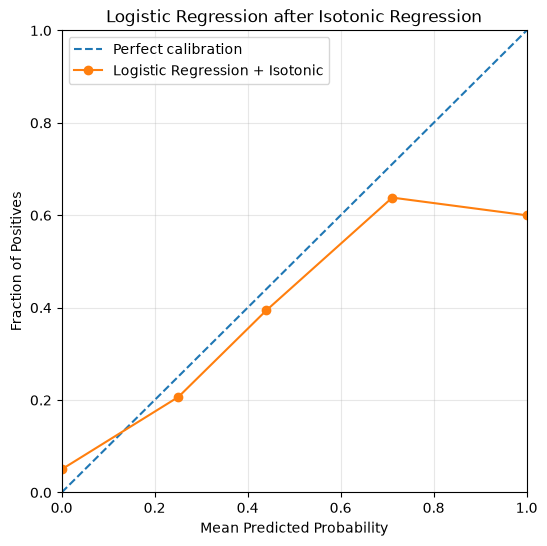

In [45]:
plot_reliability_diagram(
    y_test,
    y_prob_test_lr_isotonic,
    model_label="Logistic Regression + Isotonic",
    title="Logistic Regression after Isotonic Regression",
    n_bins=5
)

### 5.8 Evaluation before and after Isotonic Regression

In [46]:
comparison_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],

    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],

    "Isotonic Regression": [
        accuracy_lr_isotonic,
        logloss_lr_isotonic,
        brier_lr_isotonic
    ]
})

display(comparison_lr)

,Metric,Before calibration,Isotonic Regression
0,Accuracy,0.746753,0.740260
1,Log-loss,0.510001,1.368946
2,Brier score,0.168656,0.175946


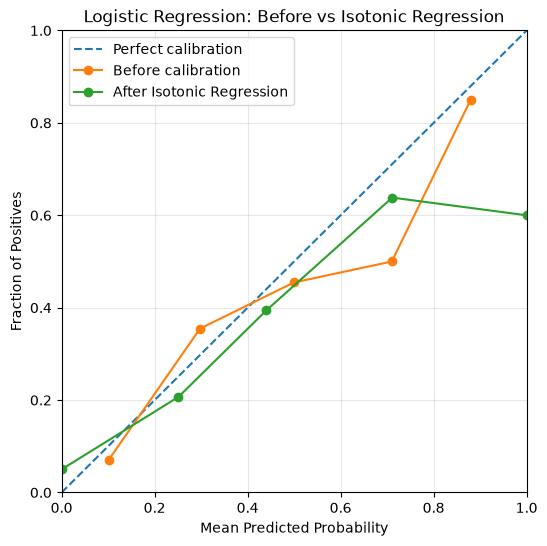

In [47]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_after=y_prob_test_lr_isotonic,
    label_before="Before calibration",
    label_after="After Isotonic Regression",
    title="Logistic Regression: Before vs Isotonic Regression",
    n_bins=5
)

Isotonic Regression does not improve the calibration of the Logistic Regression model. The Brier score increases and the Log-loss deteriorates substantially, while accuracy slightly decreases. The reliability diagram also shows poor calibration for high predicted probabilities. This suggests that Isotonic Regression may overfit the calibration set, while Platt Scaling provides a more stable calibration for this model.

In [48]:
print(np.unique(y_prob_test_lr_isotonic))

[0.         0.2        0.25       0.28571429 0.44       0.65
 0.74074074 0.77777778 1.        ]


### 5.9 Evaluation before and after calibrations

In [49]:
comparison_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],

    "Before calibration": [
        accuracy_lr,
        logloss_lr,
        brier_lr
    ],

    "Platt Scaling": [
        accuracy_lr_platt,
        logloss_lr_platt,
        brier_lr_platt
    ],

    "Isotonic Regression": [
        accuracy_lr_isotonic,
        logloss_lr_isotonic,
        brier_lr_isotonic
    ]
})

display(comparison_lr)

,Metric,Before calibration,Platt Scaling,Isotonic Regression
0,Accuracy,0.746753,0.740260,0.740260
1,Log-loss,0.510001,0.503197,1.368946
2,Brier score,0.168656,0.166436,0.175946


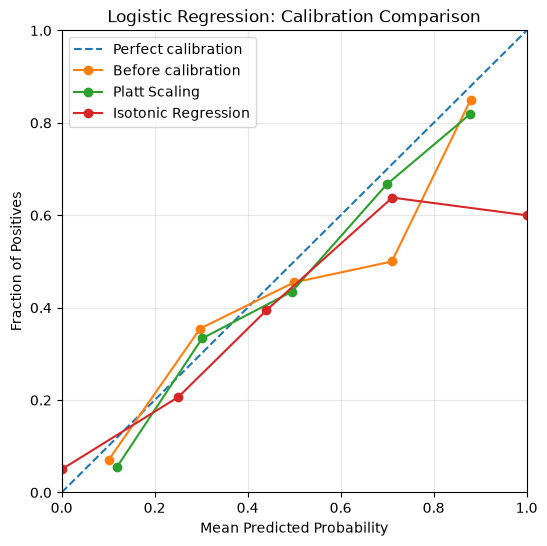

In [50]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_platt=y_prob_test_lr_platt,
    y_prob_isotonic=y_prob_test_lr_isotonic,
    title="Logistic Regression: Calibration Comparison",
    n_bins=5
)

Overall, Platt Scaling provides the best calibration for Logistic Regression. It slightly improves both Log-loss and Brier score, while causing only a small decrease in accuracy. In contrast, Isotonic Regression performs substantially worse, especially in terms of Log-loss, suggesting that its greater flexibility may lead to overfitting on the calibration set. Therefore, Platt Scaling appears to be the more suitable calibration method for this model.

## 6. Random Forest

### 6.1 Train Random Forest

In [51]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Predicted Probabilities

In [52]:
y_prob_test_rf = rf.predict_proba(x_test)[:, 1]

In [53]:
y_prob_cal_rf = rf.predict_proba(x_cal)[:, 1]

#### Predicted Classes

In [54]:
y_pred_test_rf = rf.predict(x_test)

### 6.2 Evaluation before calibration

In [55]:
accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
logloss_rf = log_loss(y_test, y_prob_test_rf)
brier_rf = brier_score_loss(y_test, y_prob_test_rf)

print(f"Accuracy:    {accuracy_rf:.4f}")
print(f"Log-loss:    {logloss_rf:.4f}")
print(f"Brier score: {brier_rf:.4f}")

Accuracy:    0.7208
Log-loss:    0.5470
Brier score: 0.1863


Accuracy: higher values indicate better classification performance.

Log-loss: lower values indicate better probabilistic predictions.

Brier score: lower values indicate better calibrated probability estimates.

#### Reliability diagram before calibration

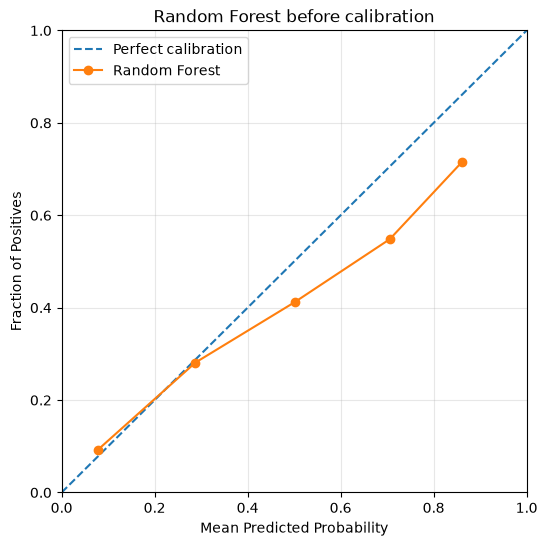

In [56]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf,
    model_label="Random Forest",
    title="Random Forest before calibration",
    n_bins=5
)

Before calibration, the Random Forest achieves an accuracy of 0.7208, with a Log-loss of 0.5470 and a Brier score of 0.1863. The reliability diagram shows that the model is reasonably calibrated for low predicted probabilities, while larger deviations from perfect calibration appear for medium and high probabilities, where the model tends to overestimate the probability of the positive class. This suggests that probability calibration may improve the reliability of the Random Forest predictions.

### 6.3 Calibration with Platt Scaling

Platt Scaling is used to correct the probabilities produced by a model without retraining the model itself. Platt uses a separate set of data (the calibration set) to understand what actually happens in practice.

Transform the score into a probability using a sigmoid: 
sigmoid(A * score + B) = 1 / (1 + exp(-(A * score + B)))

Platt Scaling does not aim to make the model better at classification; instead, it aims to make the model's confidence in its predictions more reliable.

Platt Scaling is applied using the independent calibration set.  
The method learns a sigmoid transformation from the model scores to calibrated probabilities, without retraining the original classifier.

In [57]:
platt_rf = PlattScaling(
    learning_rate=0.01,
    max_iter=10000,
    tolerance=1e-7
)

In [58]:
platt_rf.fit(y_prob_cal_rf, y_cal)

In [59]:
print(f"A: {platt_rf.a:.6f}")
print(f"B: {platt_rf.b:.6f}")

A: 3.114145
B: -1.837623


#### Predicted Probabilities

In [60]:
y_prob_test_rf_platt = platt_rf.predict_proba(y_prob_test_rf)

#### Predicted Classes

In [61]:
y_pred_test_rf_platt = (y_prob_test_rf_platt >= 0.5).astype(int)

### 6.4 Evaluation after Platt Scaling

In [62]:
accuracy_rf_platt = accuracy_score(y_test, y_pred_test_rf_platt)
logloss_rf_platt = log_loss(y_test, y_prob_test_rf_platt)
brier_rf_platt = brier_score_loss(y_test, y_prob_test_rf_platt)

print(f"Accuracy:    {accuracy_rf_platt:.4f}")
print(f"Log-loss:    {logloss_rf_platt:.4f}")
print(f"Brier score: {brier_rf_platt:.4f}")

Accuracy:    0.7078
Log-loss:    0.5426
Brier score: 0.1818


#### Reliability diagram after calibration

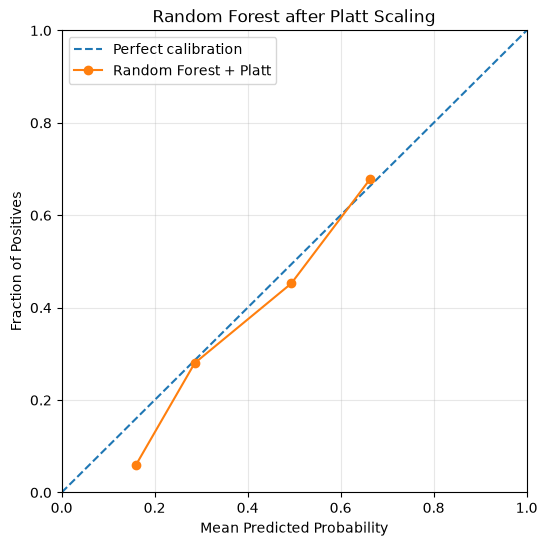

In [63]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf_platt,
    model_label="Random Forest + Platt",
    title="Random Forest after Platt Scaling",
    n_bins=5
)

### 6.5 Evaluation before and after Platt Scaling

In [64]:
comparison_platt_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "After Platt": [
        accuracy_rf_platt,
        logloss_rf_platt,
        brier_rf_platt
    ]
})

display(comparison_platt_rf)

,Metric,Before calibration,After Platt
0,Accuracy,0.720779,0.707792
1,Log-loss,0.547029,0.542633
2,Brier score,0.186252,0.181841


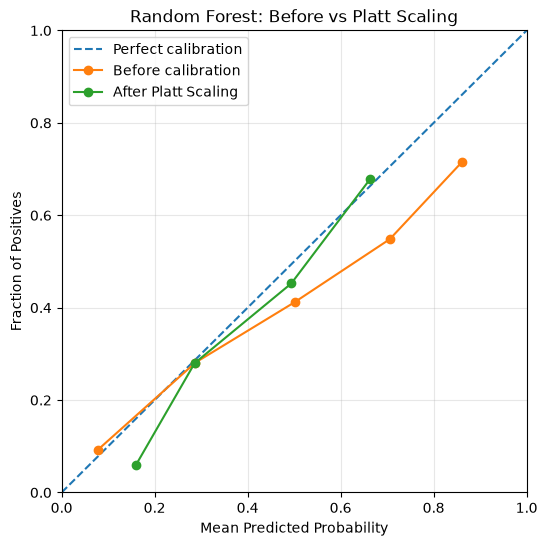

In [65]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_after=y_prob_test_rf_platt,
    label_before="Before calibration",
    label_after="After Platt Scaling",
    title="Random Forest: Before vs Platt Scaling",
    n_bins=5
)

Platt Scaling slightly improves the probabilistic performance of the Random Forest. Both Log-loss and Brier score decrease after calibration, while accuracy shows a small reduction. The reliability diagram also shows that the calibrated probabilities are generally closer to the perfect calibration line, particularly for medium and high predicted probabilities. Overall, Platt Scaling provides a modest improvement in probability calibration.

### 6.6 Calibration with Isotonic Regression

Isotonic Regression is a non-parametric calibration method that learns a monotonic mapping between model scores and observed outcomes. 
It only requires that higher model scores should correspond to equal or higher calibrated probabilities.

The method fits a non-decreasing stepwise function on an independent calibration set, typically using the Pair-Adjacent Violators (PAV) algorithm. 
Isotonic Regression is more flexible than Platt Scaling, but it can overfit when the calibration set is small.

Idea: more score --> no less calibrated probability --> it does not impose a shape but only that it is increasing

In [66]:
isotonic_rf = IsotonicRegression()

In [67]:
isotonic_rf.fit(
    y_prob_cal_rf,
    y_cal
)

#### Predicted Probabilities

In [68]:
y_prob_test_rf_isotonic = isotonic_rf.predict_proba(y_prob_test_rf)

#### Predicted Classes

In [69]:
y_pred_test_rf_isotonic = (y_prob_test_rf_isotonic >= 0.5).astype(int)

### 6.7 Evaluation after Isotonic Regression

In [70]:
accuracy_rf_isotonic = accuracy_score(y_test, y_pred_test_rf_isotonic)
logloss_rf_isotonic = log_loss(y_test, y_prob_test_rf_isotonic)
brier_rf_isotonic = brier_score_loss(y_test, y_prob_test_rf_isotonic)

print(f"Accuracy:    {accuracy_rf_isotonic:.4f}")
print(f"Log-loss:    {logloss_rf_isotonic:.4f}")
print(f"Brier score: {brier_rf_isotonic:.4f}")

Accuracy:    0.7273
Log-loss:    0.7398
Brier score: 0.1816


#### Reliability diagram after calibration

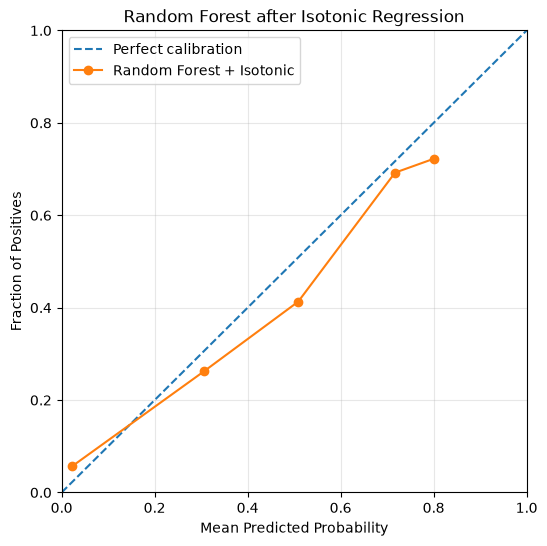

In [71]:
plot_reliability_diagram(
    y_test,
    y_prob_test_rf_isotonic,
    model_label="Random Forest + Isotonic",
    title="Random Forest after Isotonic Regression",
    n_bins=5
)

### 6.8 Evaluation before and after Isotonic Regression

In [72]:
comparison_isotonic_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "Isotonic Regression": [
        accuracy_rf_isotonic,
        logloss_rf_isotonic,
        brier_rf_isotonic
    ]
})

display(comparison_isotonic_rf)

,Metric,Before calibration,Isotonic Regression
0,Accuracy,0.720779,0.727273
1,Log-loss,0.547029,0.739825
2,Brier score,0.186252,0.181621


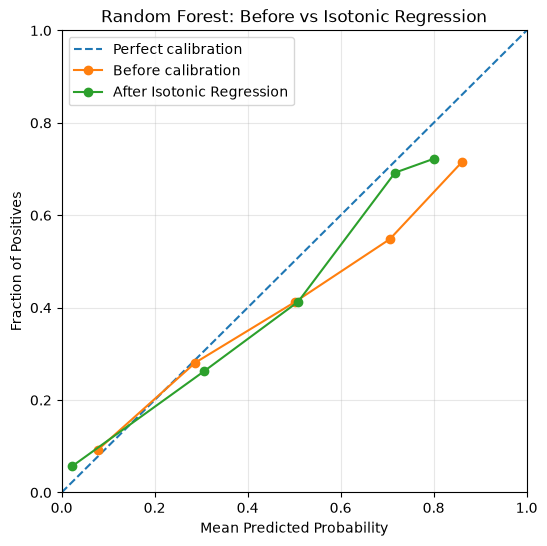

In [73]:
compare_reliability_diagrams(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_after=y_prob_test_rf_isotonic,
    label_before="Before calibration",
    label_after="After Isotonic Regression",
    title="Random Forest: Before vs Isotonic Regression",
    n_bins=5
)

Isotonic Regression produces mixed results for the Random Forest. Accuracy slightly increases and the Brier score improves, suggesting a modest improvement in the overall calibration of the predicted probabilities. However, Log-loss increases substantially, indicating that some calibrated probabilities become excessively confident when the corresponding predictions are incorrect. Therefore, despite the improvement visible in parts of the reliability diagram, Isotonic Regression does not provide a consistent improvement over the uncalibrated model.

In [74]:
print(np.unique(y_prob_test_rf_isotonic))

[0.         0.11538462 0.26315789 0.29411765 0.38888889 0.44827586
 0.5        0.6        0.71428571 0.75       0.8       ]


### 6.9 Evaluation before and after calibrations

In [75]:
comparison_rf = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Log-loss",
        "Brier score"
    ],
    "Before calibration": [
        accuracy_rf,
        logloss_rf,
        brier_rf
    ],
    "Platt Scaling": [
        accuracy_rf_platt,
        logloss_rf_platt,
        brier_rf_platt
    ],
    "Isotonic Regression": [
        accuracy_rf_isotonic,
        logloss_rf_isotonic,
        brier_rf_isotonic
    ]
})

display(comparison_rf)

,Metric,Before calibration,Platt Scaling,Isotonic Regression
0,Accuracy,0.720779,0.707792,0.727273
1,Log-loss,0.547029,0.542633,0.739825
2,Brier score,0.186252,0.181841,0.181621


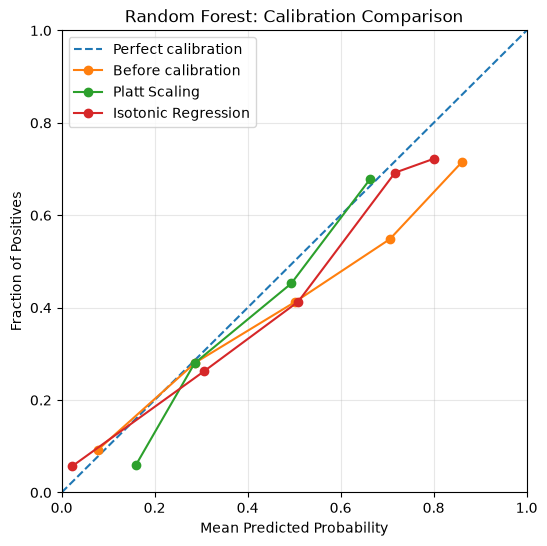

In [76]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_platt=y_prob_test_rf_platt,
    y_prob_isotonic=y_prob_test_rf_isotonic,
    title="Random Forest: Calibration Comparison",
    n_bins=5
)

Overall, both calibration methods improve the Brier score of the Random Forest, with Isotonic Regression achieving the lowest value. However, Isotonic Regression substantially increases the Log-loss, indicating that some predictions become excessively confident and incorrect. Platt Scaling, instead, slightly improves both Log-loss and Brier score, although with a small decrease in accuracy. Therefore, Platt Scaling provides the most balanced and consistent calibration improvement for the Random Forest.

## 7. Conclusion

In [77]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        " ",
        " ",
        "Random Forest",
        " ",
        " "
    ],

    "Calibration": [
        "No",
        "Platt Scaling",
        "Isotonic Regression",
        "No",
        "Platt Scaling",
        "Isotonic Regression"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_lr_platt,
        accuracy_lr_isotonic,
        accuracy_rf,
        accuracy_rf_platt,
        accuracy_rf_isotonic
    ],

    "Log-loss": [
        logloss_lr,
        logloss_lr_platt,
        logloss_lr_isotonic,
        logloss_rf,
        logloss_rf_platt,
        logloss_rf_isotonic
    ],

    "Brier score": [
        brier_lr,
        brier_lr_platt,
        brier_lr_isotonic,
        brier_rf,
        brier_rf_platt,
        brier_rf_isotonic
    ]
})

final_results.round(4)

,Model,Calibration,Accuracy,Log-loss,Brier score
0,Logistic Regression,No,0.7468,0.5100,0.1687
1,,Platt Scaling,0.7403,0.5032,0.1664
2,,Isotonic Regression,0.7403,1.3689,0.1759
3,Random Forest,No,0.7208,0.5470,0.1863
4,,Platt Scaling,0.7078,0.5426,0.1818
5,,Isotonic Regression,0.7273,0.7398,0.1816


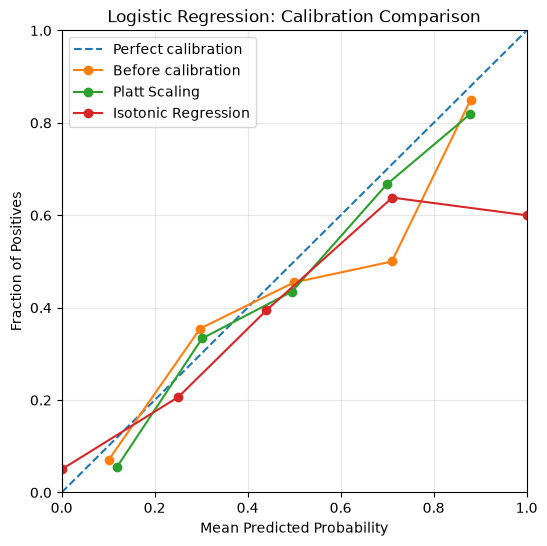

In [78]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_lr,
    y_prob_platt=y_prob_test_lr_platt,
    y_prob_isotonic=y_prob_test_lr_isotonic,
    title="Logistic Regression: Calibration Comparison",
    n_bins=5
)

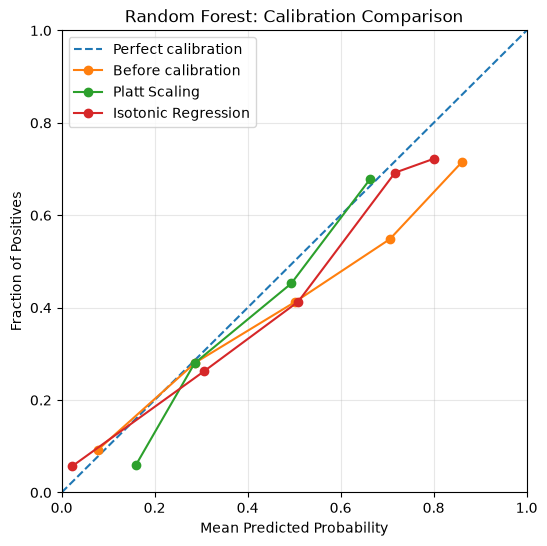

In [79]:
compare_all_calibrations(
    y_true=y_test,
    y_prob_before=y_prob_test_rf,
    y_prob_platt=y_prob_test_rf_platt,
    y_prob_isotonic=y_prob_test_rf_isotonic,
    title="Random Forest: Calibration Comparison",
    n_bins=5
)

Overall, Logistic Regression outperforms Random Forest on the Diabetes dataset, achieving higher accuracy and lower Log-loss and Brier score. Platt Scaling provides a small but consistent improvement in probability calibration for both classifiers, reducing both Log-loss and Brier score. In contrast, Isotonic Regression shows less stable results: although it can improve accuracy or Brier score in some cases, it substantially increases Log-loss, particularly for Logistic Regression. The reliability diagrams confirm that Platt Scaling generally produces a more balanced calibration. Overall, Platt Scaling appears to be the most reliable calibration method for this dataset.

These results also show that calibration does not necessarily improve classification accuracy, since its main objective is to improve the reliability of predicted probabilities rather than class predictions.